# Prepare the features

- [X] BOP features arrangement and averagings
- [O] Library Features arrangement ad averaging
  average per polihedra.
  average per structure.
  atoms in each polyhedra.
- [X] Matminer features cleanup (decide min, max or avg)
- clear feature list from correlations
- outlier detection based on features
- Feature Distribution plots

# Included averages

- moments of the total density of states :  

$$ m_0^i = \left( \sum_{j} m_j^i \right)/N_{atoms} $$

- CP averaged moments, norm to total number of atoms:

$$ 
   m_{CP}^i =  \left( \sum_{j \in CP} m_j^i \right)/N_{atoms}
$$ 

- CP averaged moments, norm atoms in CP:

$$ 
   m_{CP}^i =  \left( \sum_{j \in CP} m_j^i \right)/N_{CP}
$$ 

# but I should also include:

- correlation matrices for pair of sets

 - input : features dataframes from prev steps
 - output: clean features dataframes into picles

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rc('figure', figsize = (15,10))
plt.rc('font', size=22)
plt.rc('text', usetex=True)
import copy
import os
import numpy as np
import pdb
from tqdm.auto import tqdm 
from Tools.DatasetTools import GeneralFeaturizer as gf
dataset = 'Cr-Co-W'
descriptorlocation = os.path.join(dataset, 'Descriptors')
system = dataset.replace('-','')

import pdb

# Load Features 

In [2]:
AtomicFeaturesFile = os.path.join(descriptorlocation, 'matminer_atomic_features.pkl')
CompositionFeaturesFile = os.path.join(descriptorlocation, 'matminer_composition_features.pkl')

Coordination Number averages

In [3]:
PyscalFeaturesFile = os.path.join(descriptorlocation, 'CNAV_pyscal_steinhardt.kpl')

In [4]:
bopmodels = ['canonical', 'projections', 'projections_os']
bopfeaturesfile = {model: os.path.join(descriptorlocation, f'CNAV_{system}_initial_{model}_table_WUBIND_16.pkl') for model in bopmodels}

In [5]:
PyscalFeatures = pd.read_pickle(PyscalFeaturesFile)
BopFeatures = {model: pd.read_pickle(modelfile) for model, modelfile in bopfeaturesfile.items()}
AtomicFeatures = pd.read_pickle(AtomicFeaturesFile)
CompositionFeatures = pd.read_pickle(CompositionFeaturesFile)

# compiling FULL features 

In [6]:
AllFeatures = [AtomicFeatures,CompositionFeatures, BopFeatures['canonical'] ] # 

In [7]:
FullSetOfFeatures = pd.concat(AllFeatures, axis = 1)

# categorical features transformation

In [8]:
from sklearn import set_config
from sklearn.compose import make_column_selector
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import make_pipeline

In [9]:
cat_selector = make_column_selector(dtype_include=object)
categorical_features_names = cat_selector(FullSetOfFeatures)
CategoricalFeatures = FullSetOfFeatures[categorical_features_names]

In [10]:
oencoder = OrdinalEncoder()
oencoder.fit(X=CategoricalFeatures)
replace_categorical_features_values  = oencoder.transform(CategoricalFeatures)

In [11]:
FullSetOfFeatures[categorical_features_names] = replace_categorical_features_values

In [12]:
FullSetOfFeatures[categorical_features_names]

,HOMO_character,HOMO_element,LUMO_character,LUMO_element,compound possible,U_bind,U_bond_atom
Co_pv6W_sv6.C14-BBA.FM,0.0,2.0,0.0,2.0,0.0,415.0,251.0
Co_pv6W_sv6.C14-BBA.NM,0.0,2.0,0.0,2.0,0.0,415.0,251.0
Cr_pv6W_sv2.D0_19-A3B.FM,0.0,2.0,0.0,2.0,0.0,473.0,323.0
Cr_pv6W_sv2.D0_19-A3B.NM,0.0,2.0,0.0,2.0,0.0,473.0,323.0
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,1.0,1.0,1.0,1.0,0.0,59.0,62.0
...,...,...,...,...,...,...,...
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,0.0,1.0,0.0,1.0,0.0,40.0,85.0
Co_pv13W_sv16.chi-ABAB.NM,0.0,2.0,0.0,2.0,0.0,114.0,26.0
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.NM,1.0,1.0,1.0,1.0,0.0,59.0,62.0
W_sv1.fcc.FM,NaN,NaN,NaN,NaN,NaN,2.0,2.0


# Fix Column Names  

In [13]:
def fix_column_name(thecolumn):
    return thecolumn.replace(' ','_')

In [14]:
columns = FullSetOfFeatures.columns

In [15]:
newcolumns = {col: fix_column_name(col) for col in columns}

In [16]:
FullSetOfFeatures.rename(columns=newcolumns, inplace=True)

In [17]:
FullSetOfFeatures

,MagpieData_minimum_Number,MagpieData_maximum_Number,MagpieData_range_Number,MagpieData_mean_Number,MagpieData_avg_dev_Number,MagpieData_mode_Number,MagpieData_minimum_MendeleevNumber,MagpieData_maximum_MendeleevNumber,MagpieData_range_MendeleevNumber,MagpieData_mean_MendeleevNumber,...,Ainf_1_CN13,Ainf_1_CN14,Ainf_1_CN15,Ainf_1_CN16,Binf_1_0,Binf_1_CN12,Binf_1_CN13,Binf_1_CN14,Binf_1_CN15,Binf_1_CN16
Co_pv6W_sv6.C14-BBA.FM,27.0,74.0,47.0,69.727273,7.768595,74.0,51.0,58.0,7.0,51.636364,...,0.000000,0.000000,0.000000,-0.097097,2.071102,1.394808,0.000000,0.000000,0.000000,0.676294
Co_pv6W_sv6.C14-BBA.NM,27.0,74.0,47.0,69.727273,7.768595,74.0,51.0,58.0,7.0,51.636364,...,0.000000,0.000000,0.000000,-0.097097,2.071102,1.394808,0.000000,0.000000,0.000000,0.676294
Cr_pv6W_sv2.D0_19-A3B.FM,24.0,74.0,50.0,62.461538,17.751479,74.0,49.0,51.0,2.0,50.538462,...,0.000000,0.000000,0.000000,0.000000,1.389247,1.389247,0.000000,0.000000,0.000000,0.000000
Cr_pv6W_sv2.D0_19-A3B.NM,24.0,74.0,50.0,62.461538,17.751479,74.0,49.0,51.0,2.0,50.538462,...,0.000000,0.000000,0.000000,0.000000,1.389247,1.389247,0.000000,0.000000,0.000000,0.000000
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,24.0,74.0,50.0,41.066667,21.955556,24.0,49.0,58.0,9.0,50.866667,...,0.000000,-0.075419,-0.018909,0.000000,1.530076,0.508984,0.000000,0.817739,0.203353,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,24.0,74.0,50.0,37.533333,19.448889,24.0,49.0,58.0,9.0,50.133333,...,0.000000,-0.073633,-0.018462,0.000000,1.493851,0.496933,0.000000,0.798379,0.198539,0.000000
Co_pv13W_sv16.chi-ABAB.NM,27.0,74.0,47.0,70.468208,6.532794,74.0,51.0,58.0,7.0,51.526012,...,-0.075585,0.000000,0.000000,-0.038985,1.611500,0.000000,0.626761,0.000000,0.000000,0.258547
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.NM,24.0,74.0,50.0,41.066667,21.955556,24.0,49.0,58.0,9.0,50.866667,...,0.000000,-0.075419,-0.018909,0.000000,1.530076,0.508984,0.000000,0.817739,0.203353,0.000000
W_sv1.fcc.FM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,16.460350,16.460350,0.000000,0.000000,0.000000,0.000000


# Unsupervised feature selection 

## Variance Threashold

remove features with low variance

TODO: for each separate set of features and save clean pickles

In [18]:
from sklearn.feature_selection import VarianceThreshold

In [19]:
selector = VarianceThreshold()

In [20]:
variance_reduced = selector.fit_transform(FullSetOfFeatures)

/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/site-packages/sklearn/feature_selection/_variance_threshold.py:104: RuntimeWarning: Degrees of freedom <= 0 for slice.
  self.variances_ = np.nanvar(X, axis=0)
/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/site-packages/sklearn/feature_selection/_variance_threshold.py:112: RuntimeWarning: All-NaN slice encountered
  self.variances_ = np.nanmin(compare_arr, axis=0)


In [21]:
selectedfeatures = selector.get_support()

In [22]:
AfterVarianceFeatures = FullSetOfFeatures.iloc[:,selectedfeatures]

In [23]:
AfterVarianceFeaturesLocation = os.path.join(descriptorlocation, 'FullSetOfFeatures.pkl')

In [24]:
FullSetOfFeatures.to_pickle(AfterVarianceFeaturesLocation)

#  Correlation based feature selection

this is not started even. 

In [25]:
CORR = AfterVarianceFeatures.corr().abs()

to facilitate higly correlations removal, I will see only the upper triangle of this simmetric matrix

In [26]:
columns = np.full((CORR.shape[0],), True, dtype=bool)

In [27]:
tri_upper_corr = CORR.where(np.triu(np.ones(CORR.shape), k=1).astype(bool))

In [28]:
to_drop = [column for column in tri_upper_corr.columns if any(tri_upper_corr[column] > 0.98)]

In [29]:
len(to_drop)

355

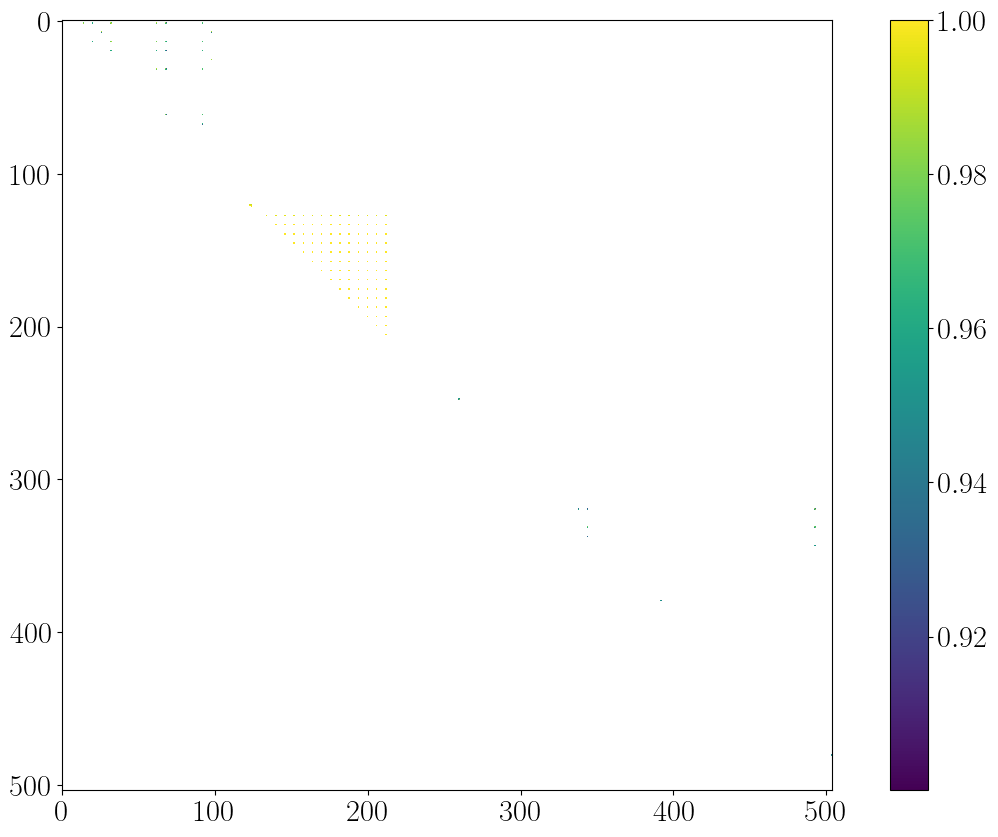

In [30]:
plt.imshow(tri_upper_corr[tri_upper_corr>0.9])
plt.colorbar()

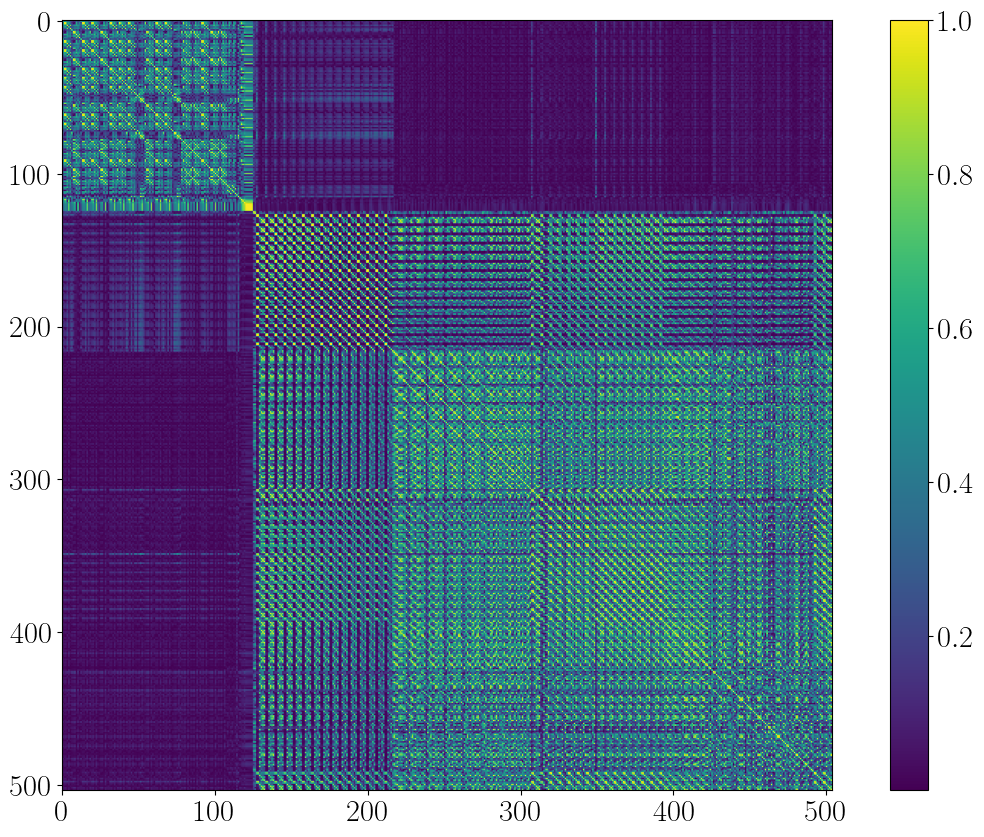

In [31]:
plt.imshow(CORR)
plt.colorbar()